In [ ]:
import pandas as pd

# Load the dataset (replace 'your_dataset.csv' with your actual filename)
df = pd.read_csv('/content/RBL1_data.csv')
print(df.head())  # Display the first few rows of the dataset

   Time [s]    PLETH  HR  PULSE  SpO2
0         0  0.43597  94   93.0  97.0
1         1  0.59042  94   93.0  97.0
2         2  0.40762  94   93.0  97.0
3         3  0.54545  92   93.0  97.0
4         4  0.39785  93   93.0  97.0


In [ ]:
print(df.info())  # Get information about data types and non-null counts
print(df.describe())  # Get summary statistics for numerical columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Time [s]  481 non-null    int64  
 1   PLETH     481 non-null    float64
 2   HR        481 non-null    int64  
 3   PULSE     468 non-null    float64
 4   SpO2      468 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 18.9 KB
None
         Time [s]       PLETH          HR       PULSE        SpO2
count  481.000000  481.000000  481.000000  468.000000  468.000000
mean   240.000000    0.467604   91.318087   91.008547   96.916667
std    138.997002    0.066542    1.012765    1.137229    0.357693
min      0.000000    0.271750   88.000000   89.000000   96.000000
25%    120.000000    0.411530   91.000000   90.000000   97.000000
50%    240.000000    0.444770   91.000000   91.000000   97.000000
75%    360.000000    0.517110   92.000000   91.000000   97.000000
max    480.000000    0.658850   95.0000

In [ ]:
df.fillna(method='ffill', inplace=True)  # Forward fill for missing values

<ipython-input-3-0933d32cc57b>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)  # Forward fill for missing values


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['PLETH']] = scaler.fit_transform(df[['PLETH']])

In [ ]:
X = df[['PLETH', 'HR', 'PULSE']]  # Features: PLETH, HR, PULSE
y = df['SpO2']  # Target: SpO2 values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Reshape input for CNN (if using 1D CNN)
X_train_cnn = X_train.values.reshape(-1, X_train.shape[1], 1)
X_test_cnn = X_test.values.reshape(-1, X_test.shape[1], 1)

# Define CNN model architecture
model_cnn = models.Sequential()
model_cnn.add(layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
# Remove the MaxPooling1D layer or decrease the pool_size to 1
#model_cnn.add(layers.MaxPooling1D(pool_size=2))
model_cnn.add(layers.MaxPooling1D(pool_size=1))
model_cnn.add(layers.Flatten())
model_cnn.add(layers.Dense(256, activation='relu'))
model_cnn.add(layers.Dense(1))  # Output layer for regression

# Compile model
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Train CNN model
model_cnn.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test), epochs=100, batch_size=32)

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5874.5332 - val_loss: 992.9085
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 484.7470 - val_loss: 180.7627
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 211.6190 - val_loss: 26.2830
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 14.9164 - val_loss: 34.1764
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 24.3711 - val_loss: 1.2774
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.5988 - val_loss: 2.8883
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8080 - val_loss: 2.2212
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4943 - val_loss: 1.2673
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0887 - val_loss: 1.2672
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8946 - val_loss: 1.3403
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0862 - val_loss: 1.2884
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Define kernel for GPR
kernel = C(1.0) * RBF(length_scale=1.0)

# Create Gaussian Process model
gpr = GaussianProcessRegressor(kernel=kernel)

# Fit GPR model on training data
gpr.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.10/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1))

In [ ]:
# Predictions using CNN Model
y_pred_cnn = model_cnn.predict(X_test_cnn)

# Predictions using GPR Model
y_pred_gpr = gpr.predict(X_test)

# Calculate performance metrics for both models
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_cnn = mean_absolute_error(y_test, y_pred_cnn)
rmse_cnn = mean_squared_error(y_test, y_pred_cnn, squared=False)

mae_gpr = mean_absolute_error(y_test, y_pred_gpr)
rmse_gpr = mean_squared_error(y_test, y_pred_gpr, squared=False)

print(f"CNN MAE: {mae_cnn}, RMSE: {rmse_cnn}")
print(f"GPR MAE: {mae_gpr}, RMSE: {rmse_gpr}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
CNN MAE: 1.1451388486881846, RMSE: 1.3175163440079867
GPR MAE: 72.99516752577323, RMSE: 84.09005250426918


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


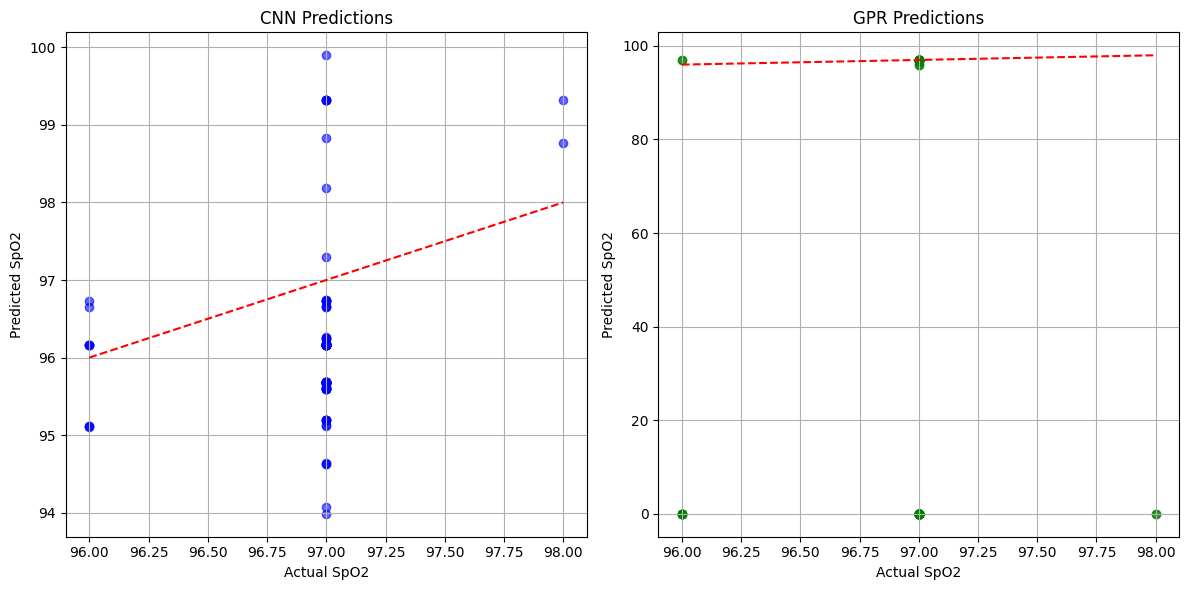

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot for CNN predictions
plt.figure(figsize=(12, 6))

# Plot for CNN predictions
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_cnn, color='blue', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Diagonal line for reference
plt.xlabel('Actual SpO2')
plt.ylabel('Predicted SpO2')
plt.title('CNN Predictions')
plt.grid()

# Plot for GPR predictions
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_gpr, color='green', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Diagonal line for reference
plt.xlabel('Actual SpO2')
plt.ylabel('Predicted SpO2')
plt.title('GPR Predictions')
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
# Save CNN Model
model_cnn.save('cnn_model.h5')

# Save GPR Model (using joblib)
import joblib

joblib.dump(gpr, 'gpr_model.pkl')

print("Models saved successfully.")

Models saved successfully.


# **TESTINGGG**

In [ ]:
import pandas as pd

# Load the new data (replace 'new_data.csv' with your actual filename)
new_data = pd.read_csv('/content/Test (3).csv')
print(new_data.head())  # Display the first few rows of the new dataset

   Time [s]    HR  PULSE    PLETH
0       0.0  77.0   75.0  0.18866
1       1.0  76.0   75.0  0.62659
2       2.0  76.0   75.0  0.17986
3       3.0  77.0   75.0  0.30108
4       4.0  76.0   75.0    0.652


In [ ]:
new_data.fillna(method='ffill', inplace=True)  # Forward fill for missing values

<ipython-input-13-df3be3b2cdc1>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  new_data.fillna(method='ffill', inplace=True)  # Forward fill for missing values


In [ ]:
# Import the necessary library and class
from sklearn.preprocessing import MinMaxScaler

# Assuming you have fitted a scaler during training
scaler = MinMaxScaler()

# Check for string values in the 'PLETH' column and try converting them
# Assuming your data should be numeric, try to handle non-numeric values by setting them to NaN
new_data['PLETH'] = pd.to_numeric(new_data['PLETH'], errors='coerce')

# Access the 'PLETH' column data correctly
pleth_data = new_data['PLETH'].values.astype(float).reshape(-1, 1)

# Normalize PLETH signal (fit only if you are using a new scaler)
new_data['PLETH'] = scaler.fit_transform(pleth_data)  # Normalize PLETH signal

In [ ]:
X_new = new_data[['PLETH', 'HR', 'PULSE']]
X_new_cnn = X_new.values.reshape(-1, X_new.shape[1], 1)  # Reshape for CNN input

In [ ]:
# Import the TensorFlow library
import tensorflow as tf

# Load the trained CNN model (if you saved it previously)
model_cnn = tf.keras.models.load_model('cnn_model.h5')

In [ ]:
# Make predictions on the new data
predictions_cnn = model_cnn.predict(X_new_cnn)

# Optionally, add predictions to your DataFrame
new_data['Predicted_SpO2'] = predictions_cnn

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
new_data.to_csv('predictions.csv', index=False)  # Save predictions to a CSV file
print("Predictions saved successfully.")

Predictions saved successfully.
